Importo tutte le varie librerie utili al nostro caso

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import r_regression, VarianceThreshold, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import *
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import cross_val_score, train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn import tree
from os import system

data = pd.read_csv('../datasets/parkinsons.txt')

Controllo com'è strutturato il dataset (in particolare, le prime 5 righe)

In [3]:
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


Controllo le feature del dataset

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

Sposto la conolla status in fondo per adattare il dataset per weka

In [5]:
df1=data.pop('status') 
data['status'] = df1

data.pop('name')

0      phon_R01_S01_1
1      phon_R01_S01_2
2      phon_R01_S01_3
3      phon_R01_S01_4
4      phon_R01_S01_5
            ...      
190    phon_R01_S50_2
191    phon_R01_S50_3
192    phon_R01_S50_4
193    phon_R01_S50_5
194    phon_R01_S50_6
Name: name, Length: 195, dtype: str

Panoramica generali dei dati del dataset

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


Controllo la distribuzione di dati utili, ad esempio sani/malati

Malati:  147
Sani:  48
Per pareggio:  99


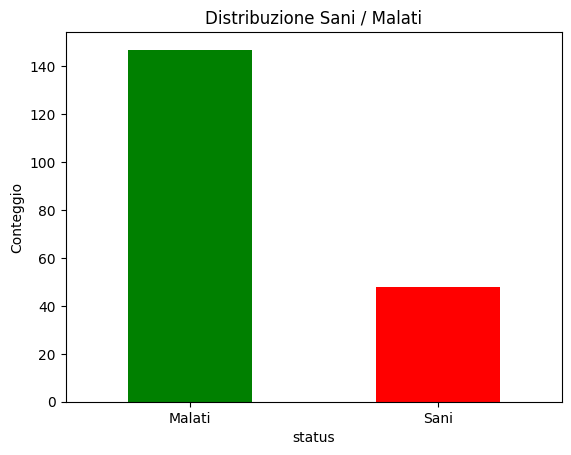

In [7]:
bar_chart = data['status'].map({0: 'Sani', 1: 'Malati'}).value_counts()
print("Malati: ", bar_chart['Malati'])
print("Sani: ", bar_chart['Sani'])

diff = bar_chart['Malati'] - bar_chart['Sani']

print("Per pareggio: ", (diff))
bar_chart.plot.bar(color=['green', 'red'])
plt.title('Distribuzione Sani / Malati')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.show()

Bilanciamento dataset (stesso numero malati/sani)

sick = data.loc[data['status'] == 1]
delete_sick = sick.sample(diff)
data.drop(index=delete_sick.index, inplace=True)

bar_chart = data['status'].map({0: 'Sani', 1: 'Malati'}).value_counts()
bar_chart.plot.bar(color=['green', 'red'])
plt.title('Distribuzione Sani / Malati')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.show()

Analisi delle feature e il loro rapporto


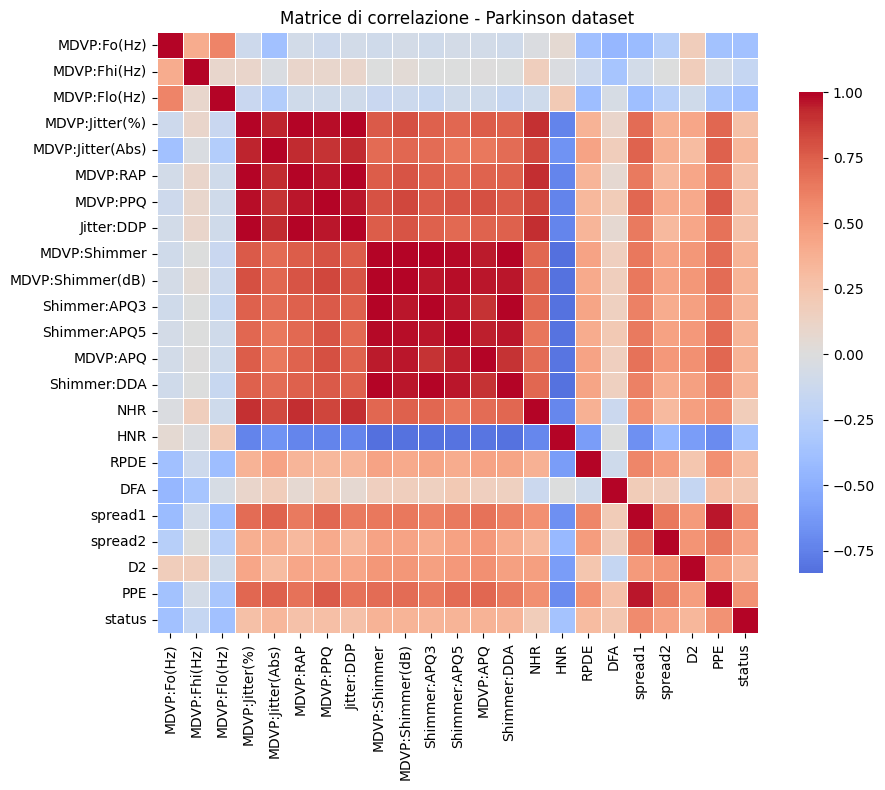

In [8]:
numeric_data = data.select_dtypes(include=['number'])

# Calcola la matrice di correlazione
corr_matrix = numeric_data.corr()

# Crea la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=False,          # mostra i valori numerici nelle celle
            fmt=".2f",           # formato a 2 decimali
            cmap='coolwarm',      # scala di colori divergente
            center=0,             # centra il colore sullo 0
            square=True,          # celle quadrate
            linewidths=0.5,       # linee di separazione tra celle
            cbar_kws={"shrink": 0.8})  # riduce la barra dei colori
plt.title('Matrice di correlazione - Parkinson dataset')
plt.tight_layout()
plt.show()

Capire quali feature sono strettamente correlate con la feature status

In [9]:
reg = r_regression(data, data['status'])

prs = pd.DataFrame(data=reg, columns=['Pearson'], index= data.columns.values)
prs.sort_values('Pearson', ascending = False, inplace = True)
prs.drop(labels='status', inplace = True)

prs

,Pearson
spread1,0.564838
PPE,0.531039
spread2,0.454842
MDVP:Shimmer,0.367430
MDVP:APQ,0.364316
Shimmer:APQ5,0.351148
MDVP:Shimmer(dB),0.350697
Shimmer:APQ3,0.347617
Shimmer:DDA,0.347608
D2,0.340232


Rimozione colonna status per preparare il dataset per l'algoritmo

In [10]:
pr_ft_np = data.columns.values
pr_ft = list(pr_ft_np)
pr_ft
'status' in pr_ft

if 'status' in pr_ft:
    pr_ft.remove('status')
    print('Status correctly removed')
else:
    print("There's no 'status' feature in the dataset")

print("Is 'status' present in the final dataset?", 'status' in pr_ft)

Status correctly removed
Is 'status' present in the final dataset? False


Isolo lo status da dataset

In [11]:
# Isolo la classe output: STATUS 0 1, creo la Y
yp = data[['status']].copy()

# Elimino l'output dalle features, credo la X
data.drop(columns=["status"], inplace=True)
Xp = data[pr_ft].copy()

Xp.shape

(195, 22)

Eliminazione feature simili

In [12]:
selector = VarianceThreshold()
selector.fit_transform(Xp)

Xp.shape

(195, 22)

Creo train e test set

In [13]:
X_train, X_test, y_train, y_test = train_test_split(Xp,
                                                    yp,
                                                    random_state=0,
                                                    test_size=0.2)

print(f'DIM TRAIN TEST SPLIT:')
print(f'X_train = {X_train.shape} || X_test = {X_test.shape}')
print(f'y_train = {y_train.shape} || y_test = {y_test.shape}')

DIM TRAIN TEST SPLIT:
X_train = (156, 22) || X_test = (39, 22)
y_train = (156, 1) || y_test = (39, 1)


Capire importanza delle feature

,Importance
PPE,0.253982
spread1,0.221368
MDVP:Fo(Hz),0.206593
spread2,0.192002
MDVP:APQ,0.178101


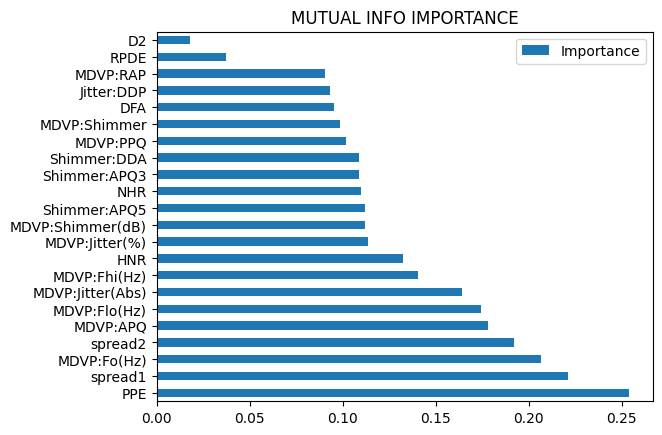

In [14]:
importance = mutual_info_classif(Xp, yp.values.ravel())

ft_import = pd.DataFrame(data=importance, columns=['Importance'])

ft_import.set_index(Xp.columns, inplace= True)

ft_import.sort_values('Importance',
                    ascending = False,
                    inplace = True)

ft_import.plot(kind='barh')
plt.title('MUTUAL INFO IMPORTANCE')
ft_import.head()


In [15]:
simplefilter("ignore", category=ConvergenceWarning)

# 1. DIVISIONE INIZIALE (Usiamo i TUOI Xp e yp!)
X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.15, random_state=42, stratify=yp)

# 2. DEFINIZIONE DEI MODELLI
models = {
    'LogisticRegression': LogisticRegression(random_state=42), 
    'NaiveBayes': GaussianNB(), 
    'KNN': KNeighborsClassifier(), 
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'MLP': MLPClassifier(random_state=42, max_iter=300) 
}

models_names = []
test_scores = []
f1_sc = []
roc = []
conf_matrs = []

# print('CLASSIFIER TESTING: \n')

for name in models:
    model = models[name]
    
    # 3. CREAZIONE DELLA PIPELINE
    # La pipeline definisce l'ordine delle operazioni: prima bilancia, poi addestra
    pipeline = Pipeline([
        ('undersampler', RandomUnderSampler(random_state=42)),
        ('classifier', model)
    ])
    
    # 4. ADDESTRAMENTO
    # L'undersampling avviene SOLO in questo momento, internamente a X_train e y_train
    pipeline.fit(X_train, y_train.values.ravel())
    
    # 5. PREVISIONE
    # Il Test Set (X_test) rimane SBILANCIATO (reale) e NON viene toccato dall'undersampler!
    y_pred_ts = pipeline.predict(X_test)
    
    # 6. CALCOLO METRICHE (Tutte calcolate rigorosamente sul Test Set)
    test_score = pipeline.score(X_test, y_test.values.ravel())
    f1 = f1_score(y_test, y_pred_ts) 
    roc_auc = roc_auc_score(y_test, y_pred_ts)
    c_m = confusion_matrix(y_test, y_pred_ts)
    
    # Salvataggio
    models_names.append(name)
    test_scores.append(test_score)
    f1_sc.append(f1)
    roc.append(roc_auc)
    conf_matrs.append(c_m)

# Creazione della tabella finale dei risultati
class_scores = pd.DataFrame(
    np.column_stack([test_scores, f1_sc, roc]),
    columns=['Test_Accuracy', 'F1_Score', 'ROC_AUC'],
    index=models_names
)

class_scores

,Test_Accuracy,F1_Score,ROC_AUC
LogisticRegression,0.700000,0.780488,0.704969
NaiveBayes,0.600000,0.647059,0.739130
KNN,0.600000,0.666667,0.689441
DecisionTree,0.833333,0.883721,0.841615
MLP,0.600000,0.666667,0.689441


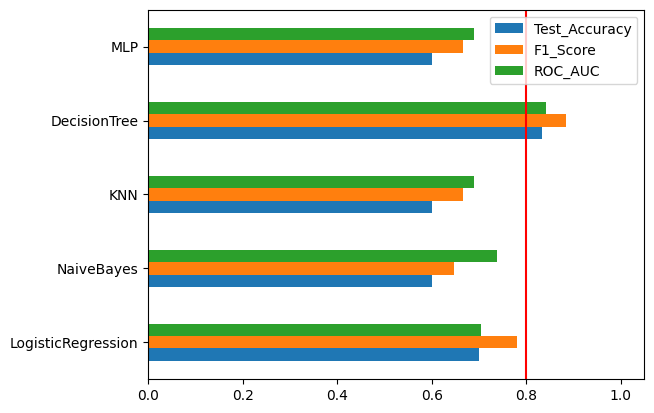

In [16]:
class_scores.plot(kind ='barh')
x = 0.8
plt.plot((20,10))
plt.axvline(x, color='r') # vertical
plt.show()

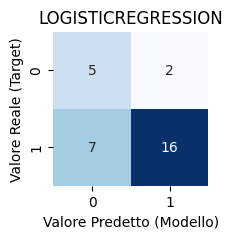

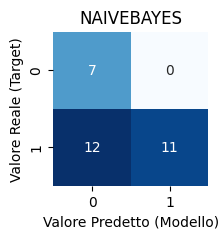

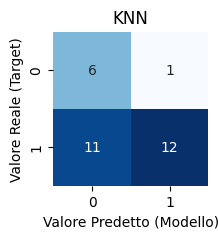

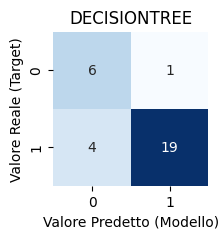

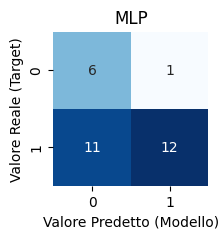

In [17]:
for i, cm in enumerate(conf_matrs):
    plt.figure(figsize=(2, 2))
    plt.title(f"{models_names[i].upper()}")
    # fmt='d' evita i numeri in notazione scientifica, cmap cambia i colori
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
    plt.ylabel('Valore Reale (Target)')
    plt.xlabel('Valore Predetto (Modello)')
    plt.show()

Best model

In [18]:
score_chose = class_scores["ROC_AUC"].max()

mod = class_scores.loc[class_scores['ROC_AUC'] == score_chose].index[0]
mod

'DecisionTree'

In [19]:
# 1. Uniamo Xp e yp
dataset_weka = pd.concat([Xp, yp], axis=1)

# 2. Creiamo il file .arff corazzato
nome_file = "dataset_esame.arff"

with open(nome_file, "w") as f:
    f.write("@RELATION parkinson_classification\n\n")
    
    # Mettiamo i nomi delle colonne tra doppi apici per evitare che WEKA impazzisca con spazi o parentesi!
    for colonna in Xp.columns:
        # Puliamo eventuali apici già presenti nel nome per sicurezza
        nome_pulito = str(colonna).replace('"', '') 
        f.write(f'@ATTRIBUTE "{nome_pulito}" NUMERIC\n')
    
    # Anche lo status tra apici
    f.write('@ATTRIBUTE "status" {0, 1}\n\n')
    
    f.write("@DATA\n")
    
    # Sostituiamo eventuali celle vuote (NaN) con '?' (lo standard di WEKA) 
    # e scriviamo i dati
    dataset_weka.fillna('?').to_csv(f, header=False, index=False)

print(f"File '{nome_file}' generato con la formattazione sicura!")

File 'dataset_esame.arff' generato con la formattazione sicura!
